In [16]:
from data import *

import numpy as np
import matplotlib.pyplot as plt

In [17]:
# generate data
d1 = 1000
d2 = 100
r = 1
p = 2.0 / d2

M = get_random_matrix(d1, d2, r) / np.sqrt(d1)
print(M)
observed_M, masks = get_uniformly_random_samples(M, p)
print(d1*d2)
print(p)
print(masks.sum())
print(observed_M)

[[0.06473543 0.06505213 0.06537587 ... 0.06397541 0.06618755 0.06392669]
 [0.06484552 0.06516276 0.06548705 ... 0.06408421 0.06630011 0.0640354 ]
 [0.06471048 0.06502706 0.06535068 ... 0.06395076 0.06616205 0.06390205]
 ...
 [0.06121641 0.06151589 0.06182203 ... 0.0604977  0.06258959 0.06045163]
 [0.05516801 0.05543791 0.0557138  ... 0.05452032 0.05640552 0.0544788 ]
 [0.06399951 0.06431261 0.06463267 ... 0.06324813 0.06543513 0.06319996]]
100000
0.02
1948
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [18]:
#eps = 0.01

cov_observe_M =  observed_M.T @ observed_M
cov_observe_count = (observed_M == 0).T @ (observed_M == 0)
diag_cov = np.diag( np.diag(cov_observe_M) )

np.count_nonzero(cov_observe_M)

3200

In [19]:
cov_observe_count = (1 * (observed_M != 0)).T @ (1 * (observed_M != 0))
cov_observe_count = cov_observe_count + (cov_observe_count == 0) * 1
T = cov_observe_M / (cov_observe_count/d1)

In [20]:
T_masks = np.nonzero(T)
MTM = M.T @ M

mask_err = T[T_masks] - MTM[T_masks]

print(np.linalg.norm(mask_err) / np.linalg.norm(MTM, 'fro'))

0.052516316513349724


In [21]:
T_p = (1.0 / p) * diag_cov + (1.0 / (p**2)) * (cov_observe_M - diag_cov)

mask_err_Tp = T_p[T_masks] - MTM[T_masks]

print(np.linalg.norm(mask_err_Tp) / np.linalg.norm(MTM, 'fro'))

1.2951804782202523


0.5824939936578736
0.42233778319218607
0.31241616470552924
0.2351485362528651
0.1802215195937844
0.1411300243139256
0.11354926636851971
0.09445448689953666
0.08160589538988414
0.0732610659138847
0.06804657452631013
0.06491407737114607
0.06310885019094206
0.062119617909801826
0.061616836331486444
0.061395637015710776
0.06133188285268972
0.06135183781372315
0.061412531571993514
0.06148950160486751
0.061569293389681125
0.061644922745443094
0.061713149209412066
0.06177284704081933
0.061824038817452034
0.06186732815755263
0.061903572323559315
0.06193369843943123
0.06195860508401245
0.06197911403118759


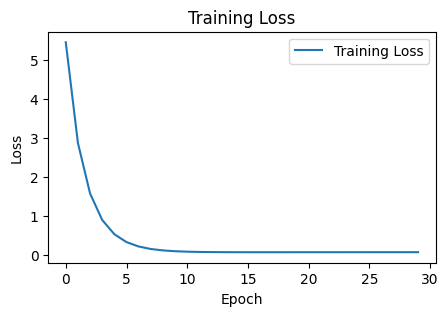

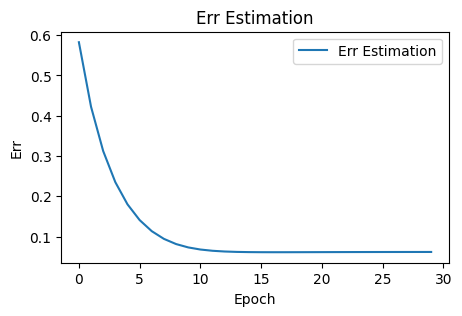

In [22]:
# impute missing values from rank-r SVD corresponding to masks

train_losses = []
err_estimates = []

epochs = 30
#lr = 0.05
X = T
T_masks = 1 * (T != 0)
for i in range(epochs):
    U, D, Vt = np.linalg.svd(X)
    D[r:] = 0
    X_update = U @ np.diag(D) @ Vt

    X = T * T_masks + X_update * (1 - T_masks)

    err = M.T @ M - X
    loss = (err**2).mean()
    train_losses.append(loss)
    relative_err = np.linalg.norm(err, 'fro') / np.linalg.norm(M.T @ M, 'fro') 
    err_estimates.append(relative_err)
    #print(relative_err)

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Err Estimation')
plt.xlabel('Epoch')
plt.ylabel('Err')
plt.title('Err Estimation')
plt.legend()

In [28]:
# run soft impute
epochs = 30
lr = 0.05
X = T
for i in range(epochs):
    U, D, Vt = np.linalg.svd(X)
    D[r:] = 0
    X_update = U @ np.diag(D) @ Vt

    #if np.linalg.norm(X - X_update, 'fro') / np.linalg.norm(X) < eps:
    #    print(i)
    #    break

    X = (1 - lr) * X + lr * X_update

    # print distance
    err = M.T @ M - X
    relative_err = np.linalg.norm(err, 'fro') / np.linalg.norm(M.T @ M)
    print(relative_err)

#print(D)

0.8139724944794224
0.8025532175972416
0.7921093669272903
0.7825673777485345
0.7738578382020578
0.7659154405642943
0.758678909267595
0.7520909071317072
0.7460979219225443
0.7406501358120571
0.7357012805871672
0.7312084815676051
0.7271320931684385
0.723435528911597
0.7200850884799933
0.7170497841439754
0.7143011685955282
0.7118131659197799
0.7095619071307353
0.7075255714098384
0.7056842339195102
0.7040197208239473
0.7025154719385278
0.701156411247707
0.6999288253784557
0.6988202499903909
0.6978193639424467
0.6969158910165966
0.696100508919053
0.6953647652357895


In [24]:
err = M.T @ M - T
relative_err = np.linalg.norm(err, 'fro') / np.linalg.norm(M.T @ M)
print(relative_err)

0.8264449400152268


In [25]:
cov_observe_count

array([[18,  1,  1, ...,  1,  1,  1],
       [ 1, 16,  1, ...,  1,  1,  2],
       [ 1,  1, 12, ...,  1,  1,  1],
       ...,
       [ 1,  1,  1, ..., 17,  1,  1],
       [ 1,  1,  1, ...,  1, 19,  1],
       [ 1,  2,  1, ...,  1,  1, 25]])

In [26]:
T

array([[3.83635745, 0.        , 0.        , ..., 0.        , 0.        ,
        3.36384124],
       [0.        , 3.99870382, 0.        , ..., 3.80727458, 3.94596971,
        4.26739494],
       [0.        , 0.        , 4.10955644, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 3.80727458, 0.        , ..., 3.55303523, 4.43095676,
        0.        ],
       [0.        , 3.94596971, 0.        , ..., 4.43095676, 4.30055737,
        3.15970731],
       [3.36384124, 4.26739494, 0.        , ..., 0.        , 3.15970731,
        3.91783809]])